# SegGPT Mask Propagation — Step-by-Step Pipeline Visualization

Given a **context frame** (with annotated stick + object masks) and a **target frame**,
this notebook walks through every intermediate step of the full touch-detection pipeline.

| Step | What it shows |
|---|---|
| **0 — Inputs** | Context image + masks, target image |
| **1 — SegGPT input** | What the model actually receives after preprocessing (448×448, ImageNet-normalised) |
| **2 — SegGPT output** | Predicted stick + object masks on the target frame, side-by-side with GT |
| **3 — Depth map** | DepthAnything V2 depth estimate on the target frame |
| **4 — Touch region** | `compute_touch_region_v2` output — contact zone gated by local depth gap |
| **5 — Summary** | All steps in a single row for quick comparison |

In [21]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path
import sys

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import torch
import torch.nn.functional as F
from transformers import (
    AutoImageProcessor,
    AutoModelForDepthEstimation,
    SegGptForImageSegmentation,
    SegGptImageProcessor,
)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from inference_script.src.touch import compute_touch_region_v2, _local_mean_depth, _erode_mask, _dilate_mask, _dilate_mask
from inference_script.src.visualization import draw_dual_mask_viz
from inference_script.src.depth import _apply_clahe, _adaptive_sharpen, _blur_score, sharpen_depth


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load models

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

_SEGGPT_ID = "BAAI/seggpt-vit-large"
seggpt_proc = SegGptImageProcessor.from_pretrained(_SEGGPT_ID)
seggpt_model = SegGptForImageSegmentation.from_pretrained(_SEGGPT_ID).to(device).eval()
print(f"SegGPT on {device}")

_DEPTH_ID = "depth-anything/Depth-Anything-V2-Small-hf"
depth_proc = AutoImageProcessor.from_pretrained(_DEPTH_ID)
depth_model = AutoModelForDepthEstimation.from_pretrained(_DEPTH_ID).to(device).eval()
print(f"DepthAnything V2 on {device}")

Loading weights: 100%|██████████| 354/354 [00:00<00:00, 1653.24it/s]


SegGPT on cuda


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 1339.94it/s]


DepthAnything V2 on cuda


## Load context + target frames

Picks the first video in Greatest Hits that has at least two fully-annotated frames
(stick mask, object mask, touch mask all present on disk).
Frame 0 → context (prompt).  Frame 1 → target (what we propagate to).

Edit `MANIFEST_OVERRIDE` to pin a specific video folder.

In [4]:
GH_MASKS = PROJECT_ROOT / "data" / "epic_kitchen" / "annotations"


def resolve_hand_path(s: dict) -> Path | None:
    """Return the hand/stick mask path that exists on disk.

    Some manifests list hand_mask_path but only _stick.png files were written,
    and vice-versa. Tries both keys, then falls back to probing the image stem.
    """
    for key in ("hand_mask_path", "stick_mask_path"):
        val = s.get(key)
        if val and Path(val).exists():
            return Path(val)
    img_stem = Path(s.get("image_path", "")).stem
    folder   = Path(s.get("image_path", "")).parent
    for suffix in ("_stick.png", "_hand.png"):
        candidate = folder / (img_stem + suffix)
        if candidate.exists():
            return candidate
    return None


def _context_key(s: dict) -> str:
    """Return the grouping key used for context sampling.

    If a sample carries ``object_name`` (EPIC Kitchen), the key is the object
    name alone so context is drawn from any video containing that object type,
    maximising sample diversity.

    For datasets without ``object_name`` (Greatest Hits, Manual), each video
    contains only one object type, so ``video_id`` alone is sufficient.
    """
    raw = s.get("object_name")
    # Guard against NaN (float) from the pandas DataFrame→dict roundtrip in
    # generate_annotations.py when some entries lacked object_name.
    object_name = raw.strip() if isinstance(raw, str) else ""
    if object_name:
        return object_name
    return s.get("video_id", "")


annotations_path = GH_MASKS / "train.json"
with open(annotations_path) as f:
    annotations = json.load(f)

context_dict = GH_MASKS / "train_ctx_index.json"
with open(context_dict) as f:
    context_dict = json.load(f)

ctx_sample = None
count = 0
for s in annotations:
    hand_path = resolve_hand_path(s)
    if hand_path is not None:
        ctx_sample = s
        count += 1
        if count >= 5:  # just pick the 5th usable sample to get some variety
            ctx_key = _context_key(s)
            context_samples = context_dict.get(ctx_key, [])
            print(f"Context samples for key '{ctx_key}': {len(context_samples)} available")
            # Load context samples
            tgt_sample = annotations[context_samples[7]] if context_samples else None
            break

assert ctx_sample is not None, "No usable sample found — check GH_MASKS path"
assert tgt_sample is not None, "No context sample found for the selected key — check train_ctx_index.json"


touch_mask_key = "touch_mask_path" if "touch_mask_path" in ctx_sample else "target_path"

# ── load images ──────────────────────────────────────────────────────────────
ctx_img  = Image.open(ctx_sample["image_path"]).convert("RGB")
ctx_stick = Image.open(hand_path).convert("L")
ctx_obj   = Image.open(ctx_sample["object_mask_path"]).convert("L")
ctx_touch = Image.open(ctx_sample[touch_mask_key]).convert("L")

tgt_img   = Image.open(tgt_sample["image_path"]).convert("RGB")
tgt_stick_gt = Image.open(resolve_hand_path(tgt_sample)).convert("L")
tgt_obj_gt   = Image.open(tgt_sample["object_mask_path"]).convert("L")
tgt_touch_gt = Image.open(tgt_sample[touch_mask_key]).convert("L")

ctx_img_np = np.array(ctx_img)
tgt_img_np = np.array(tgt_img)

print(f"Image : {ctx_img_np.shape}  —  {ctx_sample['image_path']}")
print(f"Hand  : {hand_path}")
print(f"Context Image : {ctx_img_np.shape}  —  {tgt_sample['image_path']}")

Context samples for key 'cup': 43 available
Image : (1080, 1920, 3)  —  /home/doterog/repos/uva/research/FOMO/touch_from_segmentation/data/epic_kitchen/frames/P01_104/P01_104_frame_0000005176.jpg
Hand  : /home/doterog/repos/uva/research/FOMO/touch_from_segmentation/data/epic_kitchen/masks/P01_104/P01_104_frame_0000005176_p0_hand.png
Context Image : (1080, 1920, 3)  —  /home/doterog/repos/uva/research/FOMO/touch_from_segmentation/data/epic_kitchen/frames/P01_104/P01_104_frame_0000000053.jpg


## Helpers

In [5]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def denorm(tensor_chw, mean=IMAGENET_MEAN, std=IMAGENET_STD) -> np.ndarray:
    arr = tensor_chw.numpy().transpose(1, 2, 0)
    return np.clip(arr * std + mean, 0.0, 1.0)


def overlay(img_np, mask_np, color=(0, 200, 80), alpha=0.5) -> np.ndarray:
    out = img_np.astype(float)
    m = mask_np > 0
    for c, v in enumerate(color):
        out[:, :, c] = np.where(m, out[:, :, c] * (1 - alpha) + v * alpha, out[:, :, c])
    return np.clip(out, 0, 255).astype(np.uint8)


def colorize_depth(depth: np.ndarray) -> np.ndarray:
    d_min, d_max = depth.min(), depth.max()
    d_norm = (depth - d_min) / (d_max - d_min) if d_max > d_min else np.zeros_like(depth)
    return (plt.get_cmap("inferno")(d_norm)[:, :, :3] * 255).astype(np.uint8)


def run_seggpt(target_pil, prompt_pil, prompt_mask_pil):
    """Run SegGPT → 2-D numpy array (H, W), 0=background 1+=foreground."""
    inputs = seggpt_proc(
        images=target_pil,
        prompt_images=prompt_pil,
        prompt_masks=prompt_mask_pil,
        return_tensors="pt",
    ).to(device)
    torch.manual_seed(SEED)
    with torch.inference_mode():
        out = seggpt_model(**inputs)
    return seggpt_proc.post_process_semantic_segmentation(
        out, target_sizes=[target_pil.size[::-1]]
    )[0].cpu().numpy()


def predict_depth(pil_img, clahe_clip: float = 0.0) -> np.ndarray:
    """Run DepthAnything V2 → float32 (H, W) in [0, 1]."""
    if clahe_clip > 0.0:
        pil_img = _apply_clahe(pil_img, clip_limit=clahe_clip)
    pil_img = _adaptive_sharpen(pil_img, _blur_score(np.array(pil_img)))
    inputs = depth_proc(images=pil_img, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.inference_mode():
        raw = depth_model(**inputs).predicted_depth
    depth = F.interpolate(
        raw.unsqueeze(1), size=(pil_img.height, pil_img.width),
        mode="bicubic", align_corners=False,
    ).squeeze().cpu().numpy()
    d_min, d_max = depth.min(), depth.max()
    return (depth - d_min) / (d_max - d_min) if d_max > d_min else np.zeros_like(depth)

# Augmentations

In [112]:

def adjust_brightness(pil_img: Image.Image, factor: float) -> Image.Image:
    """factor < 1 = darker, factor > 1 = brighter, 1.0 = original."""
    return ImageEnhance.Brightness(pil_img).enhance(factor)


def adjust_contrast(pil_img: Image.Image, factor: float) -> Image.Image:
    """factor < 1 = flat/grey, factor > 1 = high contrast, 1.0 = original."""
    return ImageEnhance.Contrast(pil_img).enhance(factor)

def gaussian_blur(pil_img: Image.Image, sigma: float) -> Image.Image:
    if sigma <= 0:
        return pil_img
    k = max(3, int(6 * sigma + 1) | 1)
    arr = cv2.GaussianBlur(np.array(pil_img), (k, k), sigma)
    return Image.fromarray(arr)

def adjust_exposure(pil_img: Image.Image, stops: float) -> Image.Image:
    """stops < 0 = darker, stops > 0 = brighter, 0.0 = original.
    Each stop doubles or halves the light (e.g. +1 = 2x, -1 = 0.5x)."""
    factor = 2 ** stops
    lut = [min(255, int((i / 255) ** (1 / factor) * 255)) for i in range(256)]
    lut = lut * 3  # R, G, B channels
    return pil_img.point(lut)

# SegGPT Pipeline

In [23]:
def seggpt_pipeline(ctx_img, ctx_stick, ctx_obj, tgt_img):
    print("Running SegGPT for stick mask...", end=" ")
    stick_pred = run_seggpt(tgt_img, ctx_img, ctx_stick)
    stick_mask = (stick_pred > 0).astype(np.uint8) * 255
    print(f"done — {stick_mask.sum() // 255} pixels foreground")

    print("Running SegGPT for object mask...", end=" ")
    obj_pred = run_seggpt(tgt_img, ctx_img, ctx_obj)
    obj_mask = (obj_pred > 0).astype(np.uint8) * 255
    print(f"done — {obj_mask.sum() // 255} pixels foreground")

    print("Running DepthAnything V2...", end=" ")
    tgt_depth = predict_depth(tgt_img)
    tgt_depth = sharpen_depth(tgt_depth, tgt_img_np, radius=4, eps=0.1)
    print("done")

    DILATION_RADIUS  = 10   # ← contact zone half-width (pixels)
    ABS_D_THRESHOLD  = 0.05 # ← max local depth gap in [0, 1] to keep a pixel

    touch_mask = compute_touch_region_v2(
        stick_mask, obj_mask, tgt_depth,
        erode_radius=0,
        dilation_radius=DILATION_RADIUS,
        abs_d_threshold=ABS_D_THRESHOLD,
        local_radius=10,
    )

    return stick_mask, obj_mask, touch_mask, tgt_depth

In [151]:
ctx_img  = Image.open(ctx_sample["image_path"]).convert("RGB")
tgt_img   = Image.open(tgt_sample["image_path"]).convert("RGB")

# ctx_img = adjust_contrast(ctx_img, 1.8)
# ctx_img = adjust_brightness(ctx_img, 1.5)
# ctx_img = gaussian_blur(ctx_img, 10)
# ctx_img = adjust_exposure(ctx_img, -1)

# tgt_img = adjust_contrast(tgt_img, 0.2)
# tgt_img = adjust_brightness(tgt_img, 1.5)
# tgt_img = gaussian_blur(tgt_img, 10)
tgt_img = adjust_exposure(tgt_img, 1.5)


ctx_img_np = np.array(ctx_img)
tgt_img_np = np.array(tgt_img)

---
## Step 0 — Inputs

Context frame with its ground-truth stick + object masks, and the raw target frame.

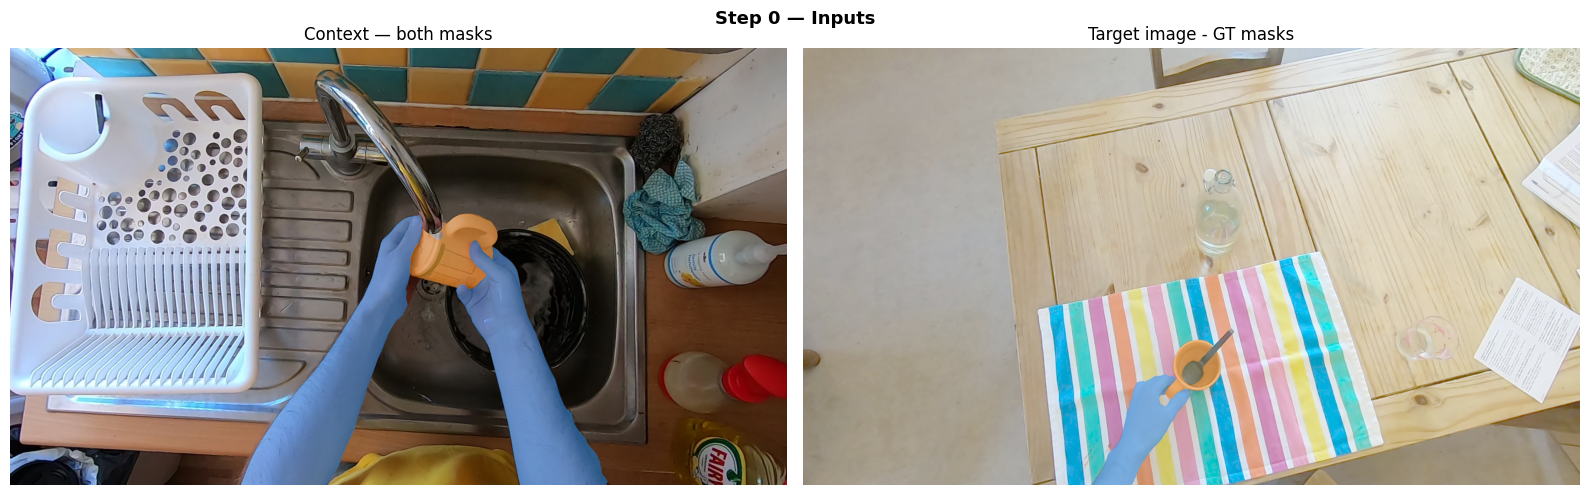

In [152]:
ctx_stick_np = np.array(ctx_stick)
ctx_obj_np   = np.array(ctx_obj)

tgt_stick_gt_np = np.array(tgt_stick_gt)
tgt_obj_gt_np   = np.array(tgt_obj_gt)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(overlay(overlay(ctx_img_np, ctx_stick_np, (30, 150, 255)), ctx_obj_np, (255, 140, 30)))
axes[0].set_title("Context — both masks")

axes[1].imshow(overlay(overlay(tgt_img_np, tgt_stick_gt_np, (30, 150, 255)), tgt_obj_gt_np, (255, 140, 30)))
axes[1].set_title(f"Target image - GT masks")

for ax in axes:
    ax.axis("off")

fig.suptitle("Step 0 — Inputs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

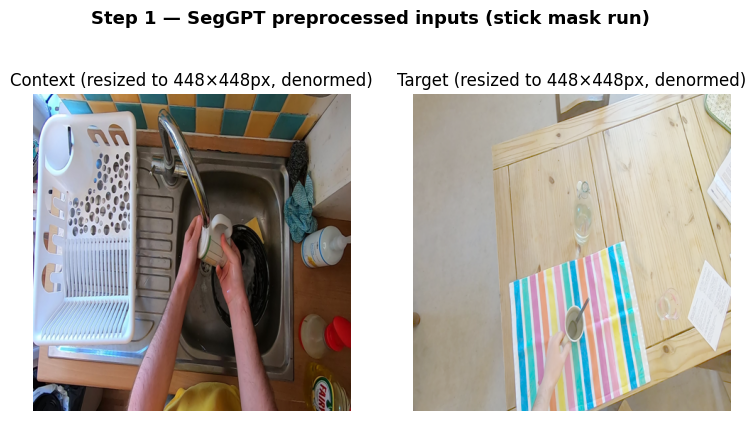

In [153]:
# Run the processor (stick mask — same layout for object mask)
proc_out = seggpt_proc(
    images=tgt_img,
    prompt_images=ctx_img,
    prompt_masks=ctx_stick,
    return_tensors="pt",
)

ctx_seen = denorm(proc_out["prompt_pixel_values"][0])
tgt_seen = denorm(proc_out["pixel_values"][0])

fig, axes = plt.subplots(1, 2, figsize=(9, 5))

axes[0].imshow(ctx_seen)
axes[0].set_title(f"Context (resized to {ctx_seen.shape[1]}×{ctx_seen.shape[0]}px, denormed)")

axes[1].imshow(tgt_seen)
axes[1].set_title(f"Target (resized to {tgt_seen.shape[1]}×{tgt_seen.shape[0]}px, denormed)")


for ax in axes:
    ax.axis("off")

fig.suptitle("Step 1 — SegGPT preprocessed inputs (stick mask run)", fontsize=13, fontweight="bold")
# plt.tight_layout()
plt.show()

In [154]:
stick_mask, obj_mask, touch_mask, tgt_depth = seggpt_pipeline(ctx_img, ctx_stick, ctx_obj, tgt_img)

Running SegGPT for stick mask... done — 35256 pixels foreground
Running SegGPT for object mask... done — 25138 pixels foreground
Running DepthAnything V2... done


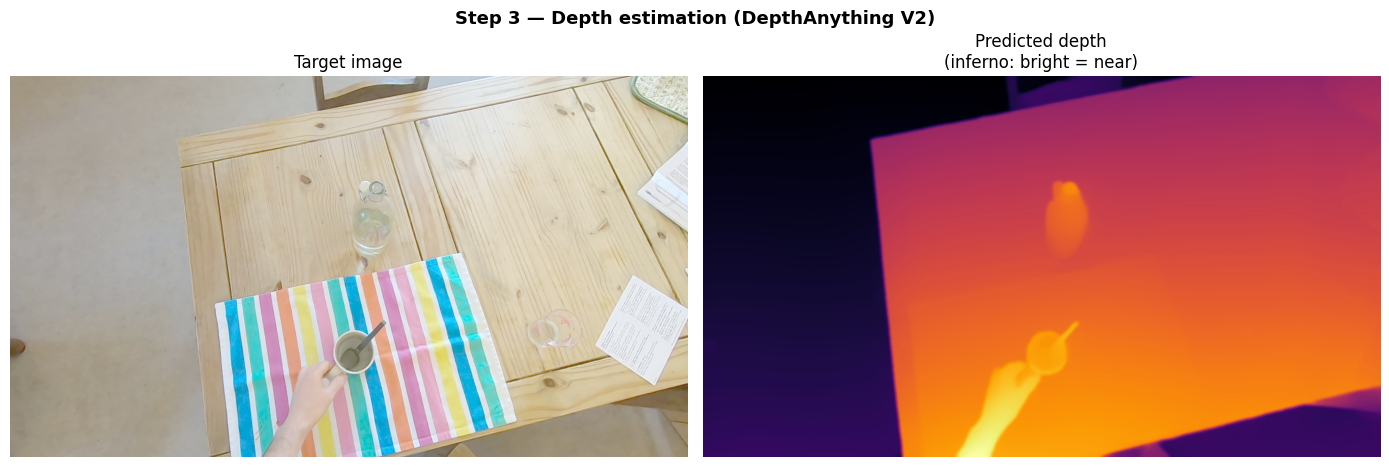

In [155]:
tgt_depth_viz = colorize_depth(tgt_depth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(tgt_img)
axes[0].set_title("Target image")

axes[1].imshow(tgt_depth_viz)
axes[1].set_title("Predicted depth\n(inferno: bright = near)")

for ax in axes:
    ax.axis("off")

fig.suptitle("Step 3 — Depth estimation (DepthAnything V2)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

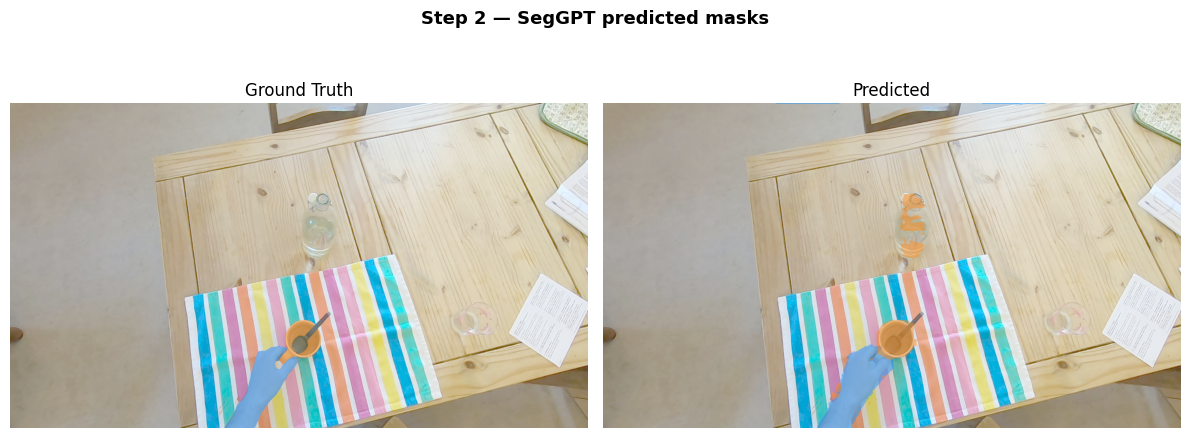

Stick  IoU: 0.780
Object IoU: 0.346


In [156]:
tgt_stick_gt_np = np.array(tgt_stick_gt)
tgt_obj_gt_np   = np.array(tgt_obj_gt)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(overlay(overlay(tgt_img_np, tgt_obj_gt_np, (255, 140, 30)), tgt_stick_gt_np, (30, 150, 255)))
axes[0].set_title("Ground Truth")

axes[1].imshow(overlay(overlay(tgt_img_np, stick_mask, (30, 150, 255)), obj_mask, (255, 140, 30)))
axes[1].set_title("Predicted")

for ax in axes:
    ax.axis("off")

fig.suptitle("Step 2 — SegGPT predicted masks", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

def iou(pred, gt):
    p, g = pred > 0, gt > 0
    inter = (p & g).sum()
    union = (p | g).sum()
    return inter / union if union > 0 else float("nan")

print(f"Stick  IoU: {iou(stick_mask, tgt_stick_gt_np):.3f}")
print(f"Object IoU: {iou(obj_mask,   tgt_obj_gt_np):.3f}")

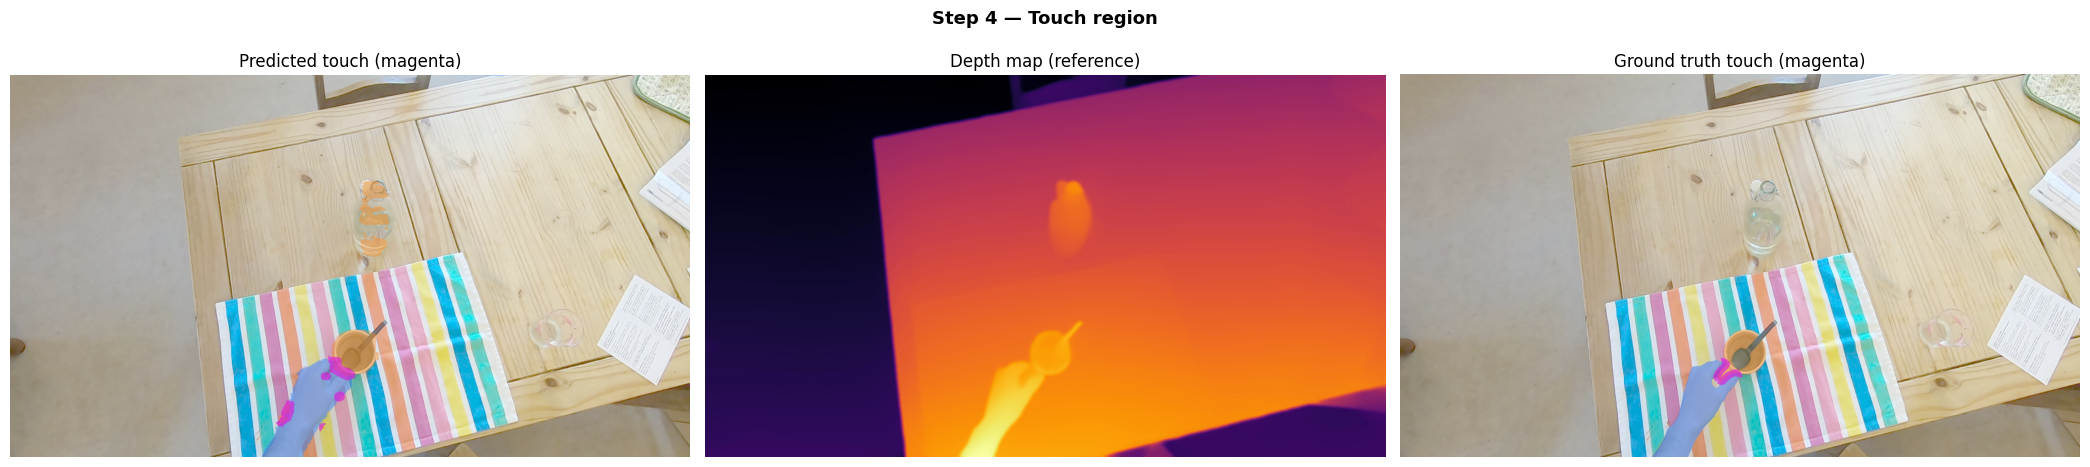

In [157]:
touch_viz = draw_dual_mask_viz(tgt_img_np, stick_mask, obj_mask, touch_mask, [], [])

has_gt_touch = tgt_touch_gt is not None
n_cols = 3 if has_gt_touch else 2

fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 5))

axes[0].imshow(touch_viz)
axes[0].set_title(
    f"Predicted touch (magenta)"
)

axes[1].imshow(tgt_depth_viz)
axes[1].set_title("Depth map (reference)")

if has_gt_touch:
    tgt_touch_gt_np = np.array(tgt_touch_gt)
    gt_stick = np.array(tgt_stick_gt) if tgt_stick_gt else stick_mask
    gt_obj   = np.array(tgt_obj_gt)   if tgt_obj_gt   else obj_mask
    gt_viz = draw_dual_mask_viz(tgt_img_np, gt_stick, gt_obj, tgt_touch_gt_np, [], [])
    axes[2].imshow(gt_viz)
    axes[2].set_title("Ground truth touch (magenta)")

for ax in axes:
    ax.axis("off")

fig.suptitle("Step 4 — Touch region", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()